# IMPORTS

In [1]:
import pandas as pd
import numpy as np
import re
import os

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Load Data + Basic Check

In [2]:
fake_df = pd.read_csv("../data/raw/Fake.csv")
real_df = pd.read_csv("../data/raw/True.csv")

fake_df["label"] = 1
real_df["label"] = 0

df = pd.concat([fake_df, real_df], ignore_index=True)

# DATA CLEANING (IMPORTANT)
df = df.drop_duplicates()
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

# Remove empty rows
df = df[df["text"].str.strip() != ""]

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df["label"].value_counts())

Shape: (44058, 5)

Missing values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64

Class distribution:
 label
1    22848
0    21210
Name: count, dtype: int64


# Exploratory Feature Analysis (BEFORE CLEANING)

       raw_word_count  raw_char_count
count    44058.000000    44058.000000
mean       410.766444     2502.418131
std        350.702070     2168.849328
min          1.000000        5.000000
25%        212.000000     1291.000000
50%        365.000000     2206.000000
75%        515.000000     3122.000000
max       8135.000000    51794.000000


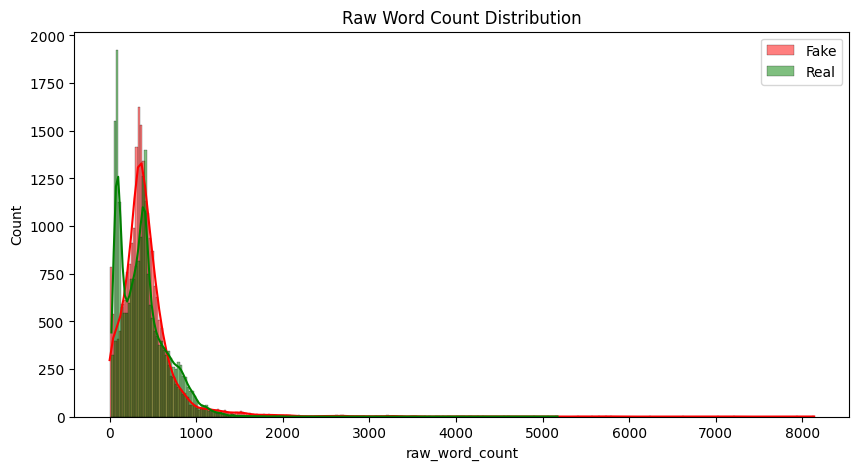

In [3]:
df["raw_word_count"] = df["text"].apply(lambda x: len(str(x).split()))
df["raw_char_count"] = df["text"].apply(len)

print(df[["raw_word_count", "raw_char_count"]].describe())

plt.figure(figsize=(10,5))
sns.histplot(df[df["label"]==1]["raw_word_count"], color="red", label="Fake", kde=True)
sns.histplot(df[df["label"]==0]["raw_word_count"], color="green", label="Real", kde=True)
plt.legend()
plt.title("Raw Word Count Distribution")
plt.show()

# Cleaning Function

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    # remove URLs + emails
    text = re.sub(r"http\S+|www\S+|\S+@\S+", "", text)

    # remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words and len(w) > 2
    ]

    return " ".join(words)

# Apply Cleaning + Feature Engineering

In [5]:
df["combined_text"] = df["title"] + " " + df["text"]

df["clean_text"] = df["combined_text"].apply(clean_text)

# IMPORTANT FIX (avoid TF-IDF errors)
df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.strip() != ""]

# FEATURE ENGINEERING (IMPORTANT FOR GRADING)
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))
df["char_count"] = df["clean_text"].apply(len)
df["unique_word_ratio"] = df["clean_text"].apply(
    lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0.0
)

print(df[["word_count", "char_count", "unique_word_ratio"]].describe())

         word_count    char_count  unique_word_ratio
count  44049.000000  44049.000000       44049.000000
mean     241.095712   1763.574587           0.699256
std      200.050383   1493.538340           0.077218
min        6.000000     40.000000           0.163466
25%      130.000000    940.000000           0.650146
50%      213.000000   1546.000000           0.696629
75%      298.000000   2165.000000           0.744318
max     4910.000000  37915.000000           1.000000


# Visualization + Save Clean Dataset

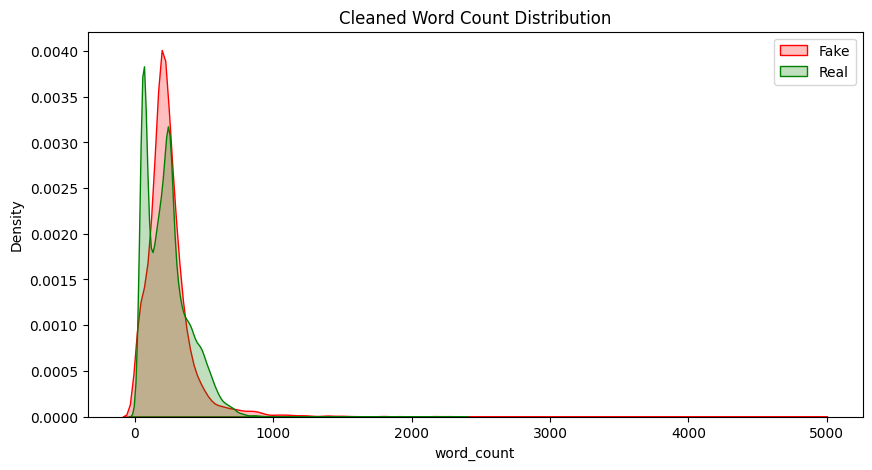

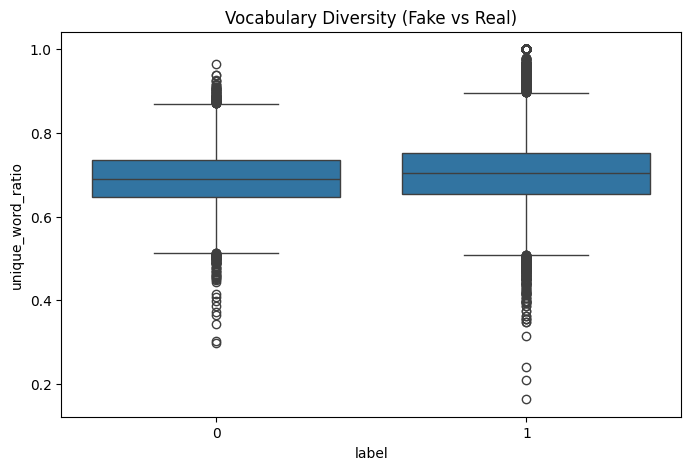

Saved successfully ✔
Final shape: (44049, 12)


In [6]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df["label"]==1]["word_count"], label="Fake", fill=True, color="red")
sns.kdeplot(df[df["label"]==0]["word_count"], label="Real", fill=True, color="green")
plt.title("Cleaned Word Count Distribution")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="unique_word_ratio", data=df)
plt.title("Vocabulary Diversity (Fake vs Real)")
plt.show()

# SAVE CLEAN DATASET (IMPORTANT FIX INCLUDED)
os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/cleaned_fake_news.csv", index=False)

print("Saved successfully ✔")
print("Final shape:", df.shape)